how can we support fast “give me 20 similar songs” queries when feature vectors are high-dimensional?

11/11-2025

Cluster the songs based on the feature vectors:<br> 
Algorithms like **k-means** or **DBSCAN** can be used for the clustering. <br>
Optionally, it is possible to build a **k-nearest-neighbour graph** from similarity scores and run a graph clustering method (e.g. **community detection**) to find “music communities”.

### **Cluster the LSH data:** 

Note: The previous step (**Step 2**), did Locality Sensitive Hashing (LSH) on the feature vectors to generate approximate nearest neighbours.
<br>
LSH maps similar songs into the same or nearby hash buckets with high probability. These buckets allow us to quickly retrieve candidate sets of similar songs without computing all pairwise distances, between every single vector.
<br>
During clustering, this pre-processing step can significantly reduce computation time, since comparisons can be limited to items within the same or similar buckets instead of the entire dataset.
<br>
<br>
Thus, LSH acts as a pre-treatment that enables scalable similarity search and accelerates the downstream clustering, performed in this notebook. 

**Load main data + LSH signatures from last notebook:**

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path

# Load LSH signatures
ARTIFACT_DIR = Path("../artifacts")
LSH = np.load("../lsh_signatures.npz")
lsh_bits = LSH["lsh_bits"]           # shape (n_items, 128)
n_tables = int(LSH["n_tables"])      # 8
n_bits_per_table = int(LSH["n_bits_per_table"])  # 16

print("LSH bits shape:", lsh_bits.shape)

# Load real features
df_main = pd.read_csv("../dataset_with_lastfm_all.csv")
df_main = df_main.reset_index(drop=True)
df_main.drop(columns=["Unnamed: 0"], inplace=True) #This is an irrelevant column, which we can just get rid of. 
X = df_main.select_dtypes(include=[np.number]).to_numpy()

n_items = lsh_bits.shape[0]


LSH bits shape: (55129, 128)


In [2]:
df_main.head(3)

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,liveness,valence,tempo,time_signature,track_genre,track_search,lfm_playcount,lfm_listeners,lfm_duration_ms,lfm_tags
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,NaN,0.676,0.461,1,...,0.358,0.715,87.917,4,acoustic,Comedy - Gen Hoshino,1908936.0,154089.0,230000.0,j-pop;japanese;rnb;jazz;pop;jpop;the best
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,NaN,0.420,0.166,1,...,0.101,0.267,77.489,4,acoustic,Ghost - Acoustic - Ben Woodward,37544.0,4502.0,149000.0,indie;rock;christian;1 in 360
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,NaN,0.438,0.359,0,...,0.117,0.120,76.332,4,acoustic,"To Begin Again - Ingrid Michaelson, ZAYN",374857.0,52055.0,210000.0,female vocalists;singer-songwriter;indie;acous...


In [3]:
#There are NA values, which need to be replaced using imputers: 
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="mean") #Can be changed later. For now the mean value will be used to impute. 
X_imputed = imputer.fit_transform(X)

X = X_imputed  # replace original X

/home/henrikk17/miniconda3/lib/python3.13/site-packages/sklearn/impute/_base.py:653: UserWarning: Skipping features without any observed values: [2]. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


Run time: Imputation takes around 46 seconds. 

In [4]:
# Split lsh_bits into tables
table_sigs = np.split(lsh_bits, n_tables, axis=1)  # 8 tables

In [5]:
#Making a list of dicts. Dicts represents the tables. 
#They allow the lookup of songs associated with different buckets for each table in the LSH signature. 
from collections import defaultdict

buckets_per_table = [defaultdict(list) for _ in range(n_tables)]

for t, table in enumerate(table_sigs):
    for i, row in enumerate(table):
        bucket_id = tuple(row.tolist())  # hashable 16-bit signature
        buckets_per_table[t][bucket_id].append(i)


In [6]:
#The list of dicts, generated above, allows us to look up the table and bits values for the LSH signatures: 
table_number = 0
bucket_id = (1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0)

print(f"The songs (index-based) in table no. {table_number} which have this particular bucket ID '{bucket_id}' are as follows:", buckets_per_table[table_number][bucket_id], sep="\n\n")

The songs (index-based) in table no. 0 which have this particular bucket ID '(1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0)' are as follows:

[0, 18710, 30279, 39885, 42457, 47845, 47992]


In [7]:
lsh_bits[0] #Looking at the 128 bits in the LSH signature for the very first datapoint/ song. 

array([1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0,
       1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0,
       1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0,
       0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0], dtype=uint8)

In [8]:
print("Amount of bits (binary yes/no questions):", len(lsh_bits[0]))
print("Amount of tables (how many pieces the bits are divided into):", n_tables)
print("Amount of bits (questions) pr. table:", n_bits_per_table)
print("Amount possible of bucket combinations pr. table:", 2**n_bits_per_table)

#Reminder: Each table contains buckets containing of 16 bits. 
#Each bucket represents each different combinations of 16 bits, for that particular table.

Amount of bits (binary yes/no questions): 128
Amount of tables (how many pieces the bits are divided into): 8
Amount of bits (questions) pr. table: 16
Amount possible of bucket combinations pr. table: 65536


**Explaining LSH and the data structure:**<br>
For each datapoint, you ask it 128 questions yes/no (position relative to the 128 random hyperplanes)? Depending on the position, it will either be a yes (1) or a no (0). (Question could e.g. be "is the coordinate in the direction of the normal vector of the given hyperplane? [yes/no]").
If you have, e.g., 8 tables, you start looking at the 16 answers to the questions at a time. (128questions/8tables=16). In other words, if the sequence of answers in table no. 1 is [1,0,...,1,1,0] (length of 16 questions), then this is a unique fingerprint. This specific sequence of answers/ fingerprint for this particular table is called a "bucket". There are several combination options when you have 16 questions in your bucket. In fact, there are 2^16 = 65536 combination options, i.e. there can be 65536 different buckets in this table! If 2 items end up in the same bucket for table 1, then they have identical answers for the first 16 questions. 
Similar datapoints will be on the same side of most hyperplanes, i.e. get mostly the same answers to questions. The pattern in their answers (bits) will be highly similar. If two items differ in only 1 or 2 answers (bits) out of 16, they go in different buckets. But across 8 tables, they'll likely match in at least one table.

In [9]:
#Checking that bucket size looks correct: 
bucket_sizes = [len(members) for table in buckets_per_table for members in table.values()]
print("Total hash buckets:", len(bucket_sizes))
print("Average bucket size:", np.mean(bucket_sizes))

Total hash buckets: 137083
Average bucket size: 3.2172625343769834


In [10]:
print(bucket_sizes[:5]) #Amount of songs in each buckets. Does not differentiate between tables. 
#Only shows the first 5. 

[7, 7, 4, 44, 217]


In [11]:
def get_hash_values(lsh_bits, n_tables, n_bits_per_table):
    """
    Convert binary bits to integer hash values for each table.
    
    Returns: array of shape (n_items, n_tables) with integer hash values
    """
    n_items = lsh_bits.shape[0]
    hash_values = np.zeros((n_items, n_tables), dtype=np.uint32)
    
    for table_idx in range(n_tables):
        start_bit = table_idx * n_bits_per_table
        end_bit = start_bit + n_bits_per_table
        
        # Get bits for this table
        table_bits = lsh_bits[:, start_bit:end_bit]
        
        # Convert binary to integer (each row becomes one hash value)
        powers = 2 ** np.arange(n_bits_per_table)
        hash_values[:, table_idx] = table_bits @ powers
    
    return hash_values

# Get hash values for all items
hash_values = get_hash_values(lsh_bits, n_tables, n_bits_per_table)
print("Hash values shape:", hash_values.shape)  # (n_items, 8)

# Example: View all items in a specific bucket
table_idx = 0  # Choose which table (0-7)
bucket_id = hash_values[0, table_idx]  # Use item 0's hash as example

items_in_bucket = np.where(hash_values[:, table_idx] == bucket_id)[0]
print(f"\nTable {table_idx}, Bucket {bucket_id}:")
print(f"Contains {len(items_in_bucket)} items: {items_in_bucket[:10]}...")

# View these items' data
print("\nFirst few items in bucket:")
display(df_main.iloc[items_in_bucket])

Hash values shape: (55129, 8)

Table 0, Bucket 20237:
Contains 7 items: [    0 18710 30279 39885 42457 47845 47992]...

First few items in bucket:


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,liveness,valence,tempo,time_signature,track_genre,track_search,lfm_playcount,lfm_listeners,lfm_duration_ms,lfm_tags
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,NaN,0.676,0.461,1,...,0.3580,0.7150,87.917,4,acoustic,Comedy - Gen Hoshino,1908936.0,154089.0,230000.0,j-pop;japanese;rnb;jazz;pop;jpop;the best
18710,3bcp0D3nW40lkIjkrdzma6,Shavi,The Great Unknown,The Great Unknown,42,209454,NaN,0.718,0.762,7,...,0.1150,0.4180,110.066,4,deep-house,The Great Unknown - Shavi,9581.0,1752.0,209000.0,house;lithuania
30279,3BIDLsbt2mhciopVG1tuBw,Oficina G3,Depois da Guerra,Eu Sou,39,352432,NaN,0.359,0.924,8,...,0.0982,0.4220,199.910,4,gospel,Eu Sou - Oficina G3,79969.0,10430.0,353000.0,christian rock;rock;progressive rock;progressi...
39885,1JENUFFWDSsm9BS5axn9kn,Kero;Kyle Hall,We Love... Detroit (Compiled by Derrick May & ...,Zug Island,9,247882,NaN,0.708,0.746,6,...,0.1000,0.3180,125.994,4,idm,"Zug Island - Kero, Kyle Hall",684.0,400.0,247000.0,idm;electronic;glitch;experimental;11;electro;...
42457,3m2jKnyeVKdTDFphqa2vou,Crows in the Rain,You Are Dying in My Arms (the Frozen Last Gasps),You Are Still Here Floating (For a Film),12,404210,NaN,0.141,0.172,11,...,0.1170,0.0561,92.853,3,iranian,You Are Still Here Floating (For a Film) - Cro...,1841.0,265.0,404000.0,post-rock;ambient;instrumental;iranian;iran;ro...
47845,2Q7JT7o5Zx1avAOV2dLDkj,Canticuénticos,Algo Que Decirte,"Ya Va, Ya Voy",39,184760,NaN,0.455,0.610,9,...,0.2730,0.5490,95.083,4,latino,"Ya Va, Ya Voy - Canticuénticos",2589.0,565.0,0.0,NaN
47992,31FXrvpxbEhf86ipANWkBG,Sayanth S;Rahul Raj Adoor,Ennavale Adi Ennavale,Ennavale Adi Ennavale,43,248174,NaN,0.368,0.176,2,...,0.1170,0.1340,79.785,3,malay,"Ennavale Adi Ennavale - Sayanth S, Rahul Raj A...",1001.0,283.0,0.0,NaN


**Build candidate neighborhoods:**

In [12]:
#Fetching candidate neighbors, by filtering out too small buckets. 

#Contains the amount of items in each bucket. 

candidate_sets = [set() for _ in range(n_items)]

for table in buckets_per_table:
    for bucket_id, members in table.items():
        if len(members) < 5:     # skip very small buckets
            continue
        for idx in members:
            candidate_sets[idx].update(members)


In [13]:
#Content of each bucket, unrelated to tables. 

for i in range(0,3):
    print(f"len: {len(candidate_sets[i])}",candidate_sets[i])

len: 35 {0, 43011, 44420, 6021, 25611, 15243, 41491, 18710, 47261, 40094, 35623, 37804, 7349, 19641, 34874, 6587, 37441, 54596, 30279, 27464, 48840, 39885, 12760, 42457, 6624, 29537, 47845, 21225, 3562, 12778, 24171, 33396, 47992, 31737, 46972}
len: 90 {1, 46596, 36870, 15372, 45078, 49692, 3613, 11299, 1063, 2600, 4660, 28212, 38966, 28216, 37945, 32316, 48703, 52800, 67, 26697, 11860, 41558, 45153, 10873, 9854, 21632, 24198, 6282, 21644, 34446, 21670, 22700, 28846, 52911, 20148, 3253, 7356, 18625, 4806, 49866, 40140, 10961, 18646, 13549, 51441, 39679, 5378, 15631, 6418, 32019, 5907, 55063, 27418, 48935, 21289, 45870, 54578, 42291, 30002, 49971, 45884, 1346, 50500, 23877, 34636, 33105, 23399, 43367, 40302, 36207, 42862, 43890, 49547, 14735, 32150, 21405, 11680, 38823, 31144, 46505, 14771, 28595, 30646, 51645, 22974, 52161, 33219, 4037, 33248, 15339}
len: 22 {2, 24962, 20229, 49807, 31888, 16668, 33056, 45348, 6059, 39213, 8627, 16951, 18751, 16582, 11462, 24666, 37725, 13800, 53618, 1

In [14]:
print("Amount of hash buckets after removing small buckets (size less than 5):", len(candidate_sets))

Amount of hash buckets after removing small buckets (size less than 5): 55129


In [15]:
print("Avg candidate size:", np.mean([len(s) for s in candidate_sets]))
print("Max candidate size:", np.max([len(s) for s in candidate_sets]))


Avg candidate size: 69.65910863610804
Max candidate size: 524


In [16]:
max(np.max([s for s in candidate_sets]))

55128

**Remove duplicate candidate groups:**

In [17]:
unique_groups = {}  # frozen_set → list of indices

for idx, s in enumerate(candidate_sets):
    key = frozenset(s)
    if key not in unique_groups:
        unique_groups[key] = []
    unique_groups[key].append(idx)

print("Unique candidate groups, aka. hash buckets after removing duplicates:", len(unique_groups))


Unique candidate groups, aka. hash buckets after removing duplicates: 50254


**Done with data exploration |Time for LSH grouping and K-means:**

In [18]:
#Looping over all buckets in all tables and creating a dict: 

import numpy as np
from collections import defaultdict

n_items = lsh_bits.shape[0]
table_sigs = lsh_bits.reshape(n_items, n_tables, n_bits_per_table)

# buckets_per_table[t][bucket_signature] = list of item indices
buckets_per_table = [defaultdict(list) for _ in range(n_tables)]

for t in range(n_tables):
    for i in range(n_items):
        bucket_id = tuple(table_sigs[i, t])
        buckets_per_table[t][bucket_id].append(i)

In [19]:
buckets_per_table[0][(1,0,1,1,0,0,0,0,1,1,1,1,0,0,1,0)]

[0, 18710, 30279, 39885, 42457, 47845, 47992]

In [20]:
from collections import Counter, defaultdict

# collision_count[(i,j)] tells how often i and j appear in same bucket
collision_count = defaultdict(int)

for t in range(n_tables):
    for bucket, items in buckets_per_table[t].items():
        if len(items) <= 1:
            continue
        for i in items:
            for j in items:
                if i < j:
                    collision_count[(i, j)] += 1

# Build final LSH groups
min_collisions = 2  # you can set 2, 3, 4 ... depending on strictness
lsh_groups = defaultdict(list)

for (i, j), c in collision_count.items():
    if c >= min_collisions:
        lsh_groups[i].append(j)
        lsh_groups[j].append(i)


In [21]:
collision_count[(0, 39885)] #In how many tables does song no. 0 and no. 39885 have identical bits (in the same bucket).
#The answer is 2. I.e. they are in identical buckets/ overlap in 2 tables (2 out of 8 tables). 

2

In [22]:
#Making super-clusters from LSH signatures. It clusters based on when 2 or more datapoints share a lot of buckets. 

visited = set()
clusters = []

for i in range(n_items): #To 55129
    if i in visited:
        continue
    stack = [i]
    comp = [] #
    while stack:
        x = stack.pop() #Pull out most recent element. 
        if x in visited:
            continue
        visited.add(x) #If we already looked on number 1 in relation to number 1113, then 1113 in relation to 1 is not relevant. Simply skip. 
        comp.append(x) #All items in the cluster. Comp is wiped each time a new stack gets started. 
        stack.extend(lsh_groups[x])
    clusters.append(comp)

# clusters now contain LSH-based preclusters


In [23]:
print(clusters)
print("Amount of LSH clusters:", len(clusters))

[[0, 48840, 37804, 47867, 41150, 51388, 33396, 11161, 20681, 41491, 47744, 47845, 46972, 42457, 25611, 39885, 12778], [1, 51441, 43367, 40140, 4037, 20148, 9780, 2324, 28517, 49878, 23877, 38823, 46505, 28595, 41558, 27418, 36870, 10374, 45394, 48030, 50453, 13567, 20514, 48935, 48703, 34636, 10339, 54829, 16352, 46125, 45212, 9017, 4829, 9352, 15960, 54695, 29006, 10503, 51138, 50710, 9264, 47841, 50229, 52574, 30027, 42646, 47469, 53126, 47087, 31283, 40513, 33248, 53655, 28212, 13015, 5789, 11860, 10961, 30002, 2600, 13932, 43945, 37802, 37773, 24198, 25889, 10467, 1632, 52161, 34446, 14013, 50746, 3673, 7001, 54296, 45884, 3253, 67, 43336, 21405, 50500, 28216, 51710, 29402, 31051, 35112, 26697, 45870, 38966, 54308, 10588, 44514, 51160, 52702, 22347, 47652, 42267, 27338, 49993, 43071, 46205, 18262, 43890, 53641, 7299, 24285, 15360, 37345, 27383, 2965, 26951, 36945, 31144, 7510, 19663, 38377, 15777, 7524, 19798, 32150, 32019, 46596, 49971, 6762, 22974, 4660, 21289, 3613, 49373, 11360

In [24]:
print( [len(c) for c in clusters] ) #Length distribution of these clusters. 
#Note: Some of them are only 1s. 

[17, 242, 5, 30594, 227, 1, 1, 1, 3, 67, 2, 2, 6, 1, 291, 1, 1217, 482, 927, 11, 31, 75, 1, 1, 2, 1, 20, 1, 463, 1, 1, 34, 2, 3, 7, 28, 102, 7, 270, 3, 231, 14, 5, 4, 2, 1, 10, 169, 26, 1, 1, 42, 34, 20, 1, 35, 6, 56, 4, 1, 4, 248, 1, 11, 5, 1, 5, 2, 1, 14, 87, 13, 6, 8, 3, 281, 1, 27, 1, 2, 1, 4, 1, 1, 3, 1, 8, 118, 4, 1, 7, 1, 2, 13, 1, 1, 15, 117, 6, 1, 12, 60, 7, 428, 1, 2, 2, 5, 2, 10, 1, 1, 4, 1, 2, 1, 3, 1, 2, 5, 1, 1, 2, 29, 49, 98, 1, 6, 1, 4, 1, 1, 39, 1, 146, 1, 4, 2, 5, 1, 1, 8, 130, 1, 5, 25, 1, 1, 13, 32, 1, 5, 2, 3, 4, 11, 1, 86, 1, 9, 1, 1, 1, 8, 10, 27, 71, 7, 2, 1, 4, 1, 42, 1, 77, 1, 5, 1, 1, 21, 23, 1, 17, 14, 8, 44, 2, 1, 1, 7, 1, 1, 1, 2, 1, 15, 7, 4, 1, 1, 14, 1, 1, 1, 1, 2, 1, 48, 1, 1, 1, 31, 1, 1, 3, 1, 32, 7, 26, 26, 4, 1, 1, 4, 1, 4, 1, 3, 11, 2, 2, 9, 1, 2, 1, 8, 25, 1, 3, 3, 18, 1, 1, 1, 1, 1, 1, 1, 2, 1, 208, 1, 12, 1, 5, 16, 1, 1, 1, 21, 23, 3, 1, 25, 4, 20, 9, 1, 1, 2, 3, 10, 3, 1, 1, 1, 1, 1, 2, 1, 1, 4, 18, 1, 1, 2, 1, 1, 2, 1, 2, 6, 3, 2, 7, 3, 1, 1,

In [25]:
#Run LOCAL K-means inside each LSH cluster

from sklearn.cluster import KMeans

local_centroids = []

k_local = 5  # pick 2–10 depending on granularity

for comp in clusters: #Iterate over each LSH cluster
    if len(comp) < k_local:
        # centroid = mean of members
        local_centroids.append(X[comp].mean(axis=0))    #If the cluster has fewer points than k_local, 
                                                        #skip K-means and use the mean of all points in the cluster as the centroid.
        continue
    
    km = KMeans(n_clusters=k_local, n_init='auto') #Run K-means on larger clusters
    km.fit(X[comp])
    local_centroids.append(km.cluster_centers_)


In [26]:
#Inspect structure of clusters: 
print(len(clusters))
print(clusters[0])
print(len(clusters[0]))

9190
[0, 48840, 37804, 47867, 41150, 51388, 33396, 11161, 20681, 41491, 47744, 47845, 46972, 42457, 25611, 39885, 12778]
17


In [27]:
print(len(local_centroids))
print(len(local_centroids[0])) #k = 5, so there will be 5 clusters. 
print(local_centroids[0]) #5 k-means clusters which was made from the 'clusters' variable. 


9190
5
[[ 3.20000000e+01  1.54440500e+05  5.81750000e-01  6.08000000e-01
   4.75000000e+00 -7.00400000e+00  5.00000000e-01  8.24500000e-02
   2.76018050e-01  3.25525000e-02  1.97000000e-01  5.49750000e-01
   1.13841000e+02  4.00000000e+00  2.76175000e+03  8.81250000e+02
   6.00000000e+04]
 [ 5.90000000e+01  1.68533000e+05  5.89000000e-01  7.97000000e-01
   1.00000000e+00 -4.21300000e+00  1.00000000e+00  1.73000000e-01
   6.73000000e-04  0.00000000e+00  2.46000000e-02  7.87000000e-01
   1.74039000e+02  4.00000000e+00  9.05074500e+06  6.80296000e+05
   1.96000000e+05]
 [ 7.80000000e+01  2.16241000e+05  6.52500000e-01  5.79500000e-01
   4.50000000e+00 -5.61550000e+00  5.00000000e-01  2.25500000e-01
   4.15500000e-02  8.30505000e-04  2.24450000e-01  6.57000000e-01
   1.02841000e+02  4.00000000e+00  2.16942450e+06  1.90068500e+05
   2.15500000e+05]
 [ 5.00000000e+01  1.68470000e+05  6.81000000e-01  5.10500000e-01
   4.50000000e+00 -9.31250000e+00  1.00000000e+00  4.69500000e-02
   4.0115000

In [28]:
#Flatten:

#The code unifies centroids. 
#It combines all centroids (from both small and large clusters) into a single matrix, where each row is a centroid.

local_centroids = np.vstack([
    c if c.ndim == 2 else np.expand_dims(c, axis=0) #If centroid is already 2D (c.ndim == 2), use it as-is.
                                                    #If c is 1D (e.g., from a small cluster), reshape it to 2D 
                                                    #using np.expand_dims(c, axis=0). 
                                                    #This adds a new axis, converting a 1D array of shape (n_features,) to (1, n_features)
    for c in local_centroids
])

#In short: Converts shape (n_features,) to (1, n_features), for the really small clusters. 

In [29]:
print(len(local_centroids))
print(local_centroids)

11614
[[3.2000000e+01 1.5444050e+05 5.8175000e-01 ... 2.7617500e+03
  8.8125000e+02 6.0000000e+04]
 [5.9000000e+01 1.6853300e+05 5.8900000e-01 ... 9.0507450e+06
  6.8029600e+05 1.9600000e+05]
 [7.8000000e+01 2.1624100e+05 6.5250000e-01 ... 2.1694245e+06
  1.9006850e+05 2.1550000e+05]
 ...
 [5.4000000e+01 1.6922600e+05 4.9500000e-01 ... 8.4841600e+05
  1.8487600e+05 1.5400000e+05]
 [5.9000000e+01 3.1973300e+05 3.7200000e-01 ... 1.3030450e+06
  3.3234800e+05 3.2100000e+05]
 [4.5000000e+01 2.8416000e+05 5.3200000e-01 ... 8.6530000e+03
  1.3050000e+03 2.8400000e+05]]


In [30]:
#Run global K-means on local centroids:

k_global = 50  # final number of clusters

km_global = KMeans(n_clusters=k_global, n_init='auto')
km_global.fit(local_centroids)

final_centroids = km_global.cluster_centers_

In [31]:
#Assign points to the final centroid: 

from sklearn.metrics import pairwise_distances_argmin

labels_global = pairwise_distances_argmin(X, final_centroids)


In [32]:
labels_global

array([ 8,  0, 34, ..., 10, 10, 10], shape=(73608,))

PCA plot it:

In [33]:
#Making a function for PCA plotting clusters: 

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# -------------------------------------------------
# Input:
#   X               : (n_items, d) feature matrix
#   labels_global   : (n_items,) cluster assignments
# -------------------------------------------------

def plot_clusters_pca(X, labels_global, sample_size=20000):
    n = X.shape[0]

    # Optional: downsample large datasets for visualization
    if n > sample_size:
        idx = np.random.choice(n, size=sample_size, replace=False)
        X_vis = X[idx]
        labels_vis = labels_global[idx]
    else:
        X_vis = X
        labels_vis = labels_global

    # PCA → 2D
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_vis)

    # Create figure
    plt.figure(figsize=(10, 7))

    # Avoid color issues: pass labels as *a separate argument*
    # and let matplotlib assign a colormap
    scatter = plt.scatter(
        X_pca[:, 0], 
        X_pca[:, 1], 
        c=labels_vis,
        s=8,
        alpha=0.7,
        cmap="tab20"
    )

    # Add colorbar
    cbar = plt.colorbar(scatter)
    cbar.set_label("Cluster ID", rotation=270, labelpad=15)

    plt.title("PCA Visualization of LSH-accelerated K-means Clusters")
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")

    plt.tight_layout()
    plt.show()


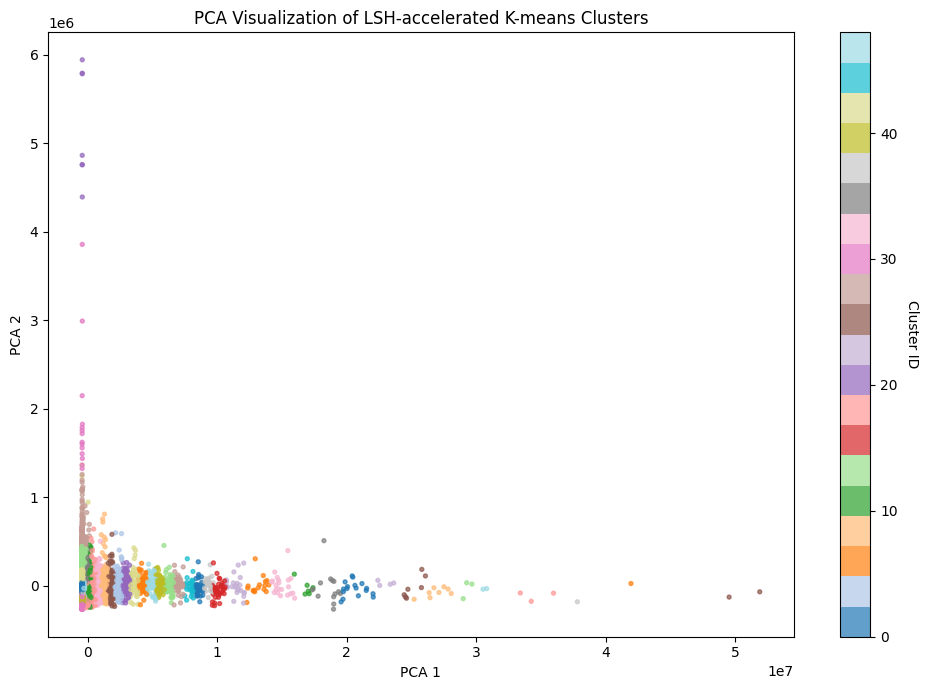

In [34]:
plot_clusters_pca(X, labels_global)

In [35]:
print(labels_global)

[ 8  0 34 ... 10 10 10]


**Run LSH-accelerated K-means:**

Run time: 14.8 seconds. 

**Global K-means but accelerated with LSH:**

In [36]:
# 1. Initialize K global centroids (K-means++)
# 2. For each iteration:
#       a. For each point: 
#              Use LSH to find candidate centroids
#              Assign point to the nearest among those candidates
#       b. Update all centroids globally
# 3. Repeat until convergence



Update: Not desired! This k-means clustering makes 5 clusters within each hash bucket. 

In [37]:
#Performing K-means clustering, using LSH signatures: 

from sklearn.cluster import KMeans

n_items = lsh_bits.shape[0] #Should not be 'len(unique_groups)', 
                            #Since, even tho we removed some hash buckets,
                            #We still need to assign cluster labels back 
                            #to the original indices (before we started removing). 

labels_global = -1 * np.ones(n_items, dtype=int)
cluster_base = 0

K = 5  # number of clusters per group

for cand_set, members in unique_groups.items():
    indices = list(cand_set)

    if len(indices) < 40:   # threshold; tune
        continue

    X_sub = X[indices]

    kmeans = KMeans(n_clusters=K, n_init="auto", random_state=42)
    sub_labels = kmeans.fit_predict(X_sub)

    # assign cluster labels back to the original indices
    for idx, label in zip(indices, sub_labels):
        labels_global[idx] = cluster_base + label

    cluster_base += K


KeyboardInterrupt: 

Run time: 21 minutes and 13 seconds. <br>
Note: Depends on computer stats.

**Saving and loading the clustering data:**

In [ ]:
#Save the clustering results:

###

if labels_global: #If you ran the k-means. 

    # Save the cluster labels
    np.save('cluster_labels.npy', labels_global)

    # Or save as CSV for easy viewing
    import pandas as pd
    pd.DataFrame({
        'item_index': np.arange(len(labels_global)),
        'cluster_label': labels_global
    }).to_csv('clustering_results.csv', index=False)

    print(f"Clustered: {np.sum(labels_global >= 0)}/{len(labels_global)} items")
    print(f"Number of clusters: {len(np.unique(labels_global[labels_global >= 0]))}")


Clustered: 52878/55129 items
Number of clusters: 11180


In [ ]:
#Load clustering results:

import numpy as np
import pandas as pd

# Load from .npy file
labels_global = np.load('cluster_labels.npy')

# OR load from CSV
df_load = pd.read_csv('clustering_results.csv')
labels_global = df_load['cluster_label'].values

# Print summary
print(f"Loaded: {len(labels_global)} items")
print(f"Clustered: {np.sum(labels_global >= 0)}/{len(labels_global)} items")
print(f"Number of clusters: {len(np.unique(labels_global[labels_global >= 0]))}")



Loaded: 55129 items
Clustered: 52878/55129 items
Number of clusters: 11180


**Inspecting the clustering results:**

In [ ]:
#Inspecting some of the clustering results: 
print(labels_global.shape)
print(labels_global[:50])


(55129,)
[134272 153619 110564 151992 150296 149180 110237 153026 146347 152225
 150132 150620 146560 116880 152230 144092 148745 153705 148496 149689
 150794 142414 147149 153165 153585 151883 152790 151120 152775 153568
 152137 152425 152364 153065 144785 152145 150809 145928 127315 152779
 153645  20185  65406 105054 151297 153214 151596 153534 145844 149670]


In [ ]:
X.shape

(73608, 18)

In [ ]:
labels_global.shape 
#Note: LSH candidate clustering only assigned labels to a subset of rows (55,129 items), 
#while X contains all features including some rows that were never clustered.

#We also need to keep this in mind, when we map the original data to the clustered data.

(55129,)

**Visualizing clustering results using PCA and T-SNE:**

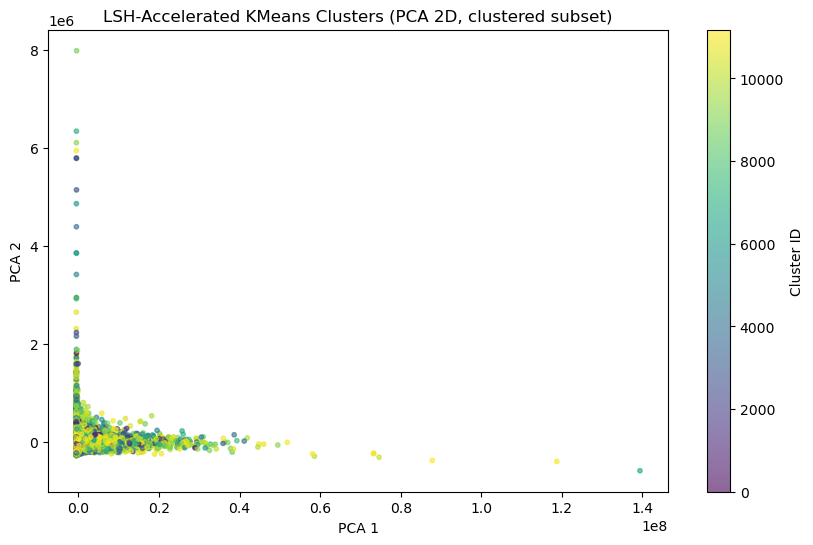

In [ ]:
# Identify clustered rows robustly (use labeled indices, handle length mismatches)
import warnings
labeled_indices = np.where(labels_global >= 0)[0]  # indices that received cluster labels
# Guard: some labeled indices may be outside the current X array (shape mismatch)
valid_mask = labeled_indices < X.shape[0]
if not np.all(valid_mask):
    warnings.warn(f"{np.sum(~valid_mask)} labeled indices are >= X.shape[0]={X.shape[0]} and will be ignored.")
    labeled_indices = labeled_indices[valid_mask]
X_clustered = X[labeled_indices]
labels = labels_global[labeled_indices].astype(int)

# PCA
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_clustered)

# Map cluster IDs to sequential integers for coloring
unique_labels = np.unique(labels)
label_map = {old: new for new, old in enumerate(unique_labels)}
labels_mapped = np.array([label_map[l] for l in labels])

plt.figure(figsize=(10,6))
plt.scatter(
    X_pca[:,0], X_pca[:,1],
    c=labels_mapped,
    s=10,
    cmap='viridis',
    alpha=0.6
)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("LSH-Accelerated KMeans Clusters (PCA 2D, clustered subset)")
plt.colorbar(label="Cluster ID")
plt.show()

Run time: 11 seconds. 

In [ ]:
df_main.head(2)

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,liveness,valence,tempo,time_signature,track_genre,track_search,lfm_playcount,lfm_listeners,lfm_duration_ms,lfm_tags
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,NaN,0.676,0.461,...,0.358,0.715,87.917,4,acoustic,Comedy - Gen Hoshino,1908936.0,154089.0,230000.0,j-pop;japanese;rnb;jazz;pop;jpop;the best
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,NaN,0.420,0.166,...,0.101,0.267,77.489,4,acoustic,Ghost - Acoustic - Ben Woodward,37544.0,4502.0,149000.0,indie;rock;christian;1 in 360


In [ ]:
df_main.shape

(73608, 26)

In [ ]:
X_clustered

array([[0.000000e+00, 7.300000e+01, 2.306660e+05, ..., 1.908936e+06,
        1.540890e+05, 2.300000e+05],
       [1.000000e+00, 5.500000e+01, 1.496100e+05, ..., 3.754400e+04,
        4.502000e+03, 1.490000e+05],
       [2.000000e+00, 5.700000e+01, 2.108260e+05, ..., 3.748570e+05,
        5.205500e+04, 2.100000e+05],
       ...,
       [5.512600e+04, 2.900000e+01, 2.508660e+05, ..., 5.680770e+05,
        1.214010e+05, 2.510000e+05],
       [5.512700e+04, 3.000000e+01, 1.526330e+05, ..., 6.650580e+05,
        2.004670e+05, 1.550000e+05],
       [5.512800e+04, 2.900000e+01, 1.200000e+05, ..., 2.107600e+04,
        1.040600e+04, 0.000000e+00]])

In [ ]:
X_clustered.shape

(52878, 18)

t-SNE:

In [ ]:
#t-SNE plot: 

from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000, verbose=1)
X_tsne = tsne.fit_transform(X_clustered)

plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels_mapped, s=10, cmap='viridis', alpha=0.6)
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("LSH-Accelerated KMeans Clusters (t-SNE 2D)")
plt.colorbar(label="Cluster ID")
plt.show()

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 55129 samples in 0.038s...
[t-SNE] Computed neighbors for 55129 samples in 29.472s...
[t-SNE] Computed conditional probabilities for sample 1000 / 55129
[t-SNE] Computed conditional probabilities for sample 2000 / 55129
[t-SNE] Computed conditional probabilities for sample 3000 / 55129
[t-SNE] Computed conditional probabilities for sample 4000 / 55129
[t-SNE] Computed conditional probabilities for sample 5000 / 55129
[t-SNE] Computed conditional probabilities for sample 6000 / 55129
[t-SNE] Computed conditional probabilities for sample 7000 / 55129
[t-SNE] Computed conditional probabilities for sample 8000 / 55129
[t-SNE] Computed conditional probabilities for sample 9000 / 55129
[t-SNE] Computed conditional probabilities for sample 10000 / 55129
[t-SNE] Computed conditional probabilities for sample 11000 / 55129
[t-SNE] Computed conditional probabilities for sample 12000 / 55129
[t-SNE] Computed conditional probabilities for sa

KeyboardInterrupt: 

Run time: More than 11 minutes. 

# Outdated - Prototyping:

### **Loading subset data and generating placeholder LSH data:**

In [ ]:
root_path = "../" #All the data is outside this folder. 

Note: If we just read the e.g. first 200 lines, we will only get the track_genre = acoustic entries.
Therefore, when making the subset, we need to mix the entries that we read. 

In [ ]:
import pandas as pd
import numpy as np

# -----------------------------
# 1. Load subset of CSV
# -----------------------------
# Load only first 200 rows (change nrows as needed)
#df = pd.read_csv(root_path+"dataset_with_lastfm_all.csv", nrows=200)

# Read whole CSV: 
df = pd.read_csv(root_path+"dataset_with_lastfm_all.csv")

# Drop 'Unnamed: 0' if present
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

# Take a random sample of 200 rows - overwrite the df, which covers the entire dataset. 
df = df.sample(n=200, random_state=42)

print("Checking how many different track genres are in the subset:")
display( pd.DataFrame(df['track_genre'].value_counts()) )


# Drop 'Unnamed: 0' if it exists
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

print("Data loaded:", df.shape)
display(df.head())

# Drop non-numeric columns if any (e.g., 'track_id','artists', etc.)
numeric_df = df.select_dtypes(include=[np.number])
print("Numeric columns used:", numeric_df.columns.tolist())


Checking how many different track genres are in the subset:


,count
track_genre,
heavy-metal,7
drum-and-bass,7
industrial,6
study,6
electronic,5
...,...
synth-pop,1
pagode,1
indian,1


Data loaded: (200, 25)


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,liveness,valence,tempo,time_signature,track_genre,track_search,lfm_playcount,lfm_listeners,lfm_duration_ms,lfm_tags
37609,2gpz5SQb1NEPPxjbSglAZK,Pappo,Buscando un Amor,Trabajo Forzado,23,248066,NaN,0.547,0.699,9,...,0.1310,0.622,75.814,4,heavy-metal,Trabajo Forzado - Pappo,4373.0,1433.0,248000.0,blues;rock;rock argentino;argentina;blues rock...
35970,3oYj1UaQtkX0R9iuaV2jMj,Eterna Inocencia,No bien abran las flores,Hojas Amarillas,31,255905,NaN,0.576,0.709,2,...,0.1250,0.579,140.003,4,hardcore,Hojas Amarillas - Eterna Inocencia,2195.0,428.0,255000.0,melodic hardcore;hardcore melodico;hardcore pu...
61541,2WkjVlKU47qVKyPUehA5eH,SONNY NITEZ,MORNING 2007,MORNING 2007,52,118763,NaN,0.752,0.485,5,...,0.3420,0.819,95.003,4,sad,MORNING 2007 - SONNY NITEZ,69823.0,11268.0,118000.0,NaN
652,4XBcShO4h4X55x9yMmyKHL,Allman Brown,1000 Years,Sweetest Thing,54,218502,NaN,0.546,0.411,2,...,0.0955,0.528,79.785,4,acoustic,Sweetest Thing - Allman Brown,326871.0,75287.0,218000.0,singer-songwriter;folk rock;indie;rock;england...
37281,7pvMOx4cYIamyNeYLVhTWS,Tren Loco,Venas De Acero,Venas De Acero,25,362520,NaN,0.534,0.949,4,...,0.5370,0.334,114.988,4,heavy-metal,Venas De Acero - Tren Loco,3454.0,858.0,408000.0,heavy metal;speed metal;argentina;heavy argent...


Numeric columns used: ['popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'lfm_playcount', 'lfm_listeners', 'lfm_duration_ms']


In [ ]:
#Different type of track genres in the list: 
print(df["track_genre"].unique()) 

['heavy-metal' 'hardcore' 'sad' 'acoustic' 'blues' 'forro' 'iranian'
 'country' 'j-idol' 'emo' 'mandopop' 'r-n-b' 'industrial' 'bluegrass'
 'alt-rock' 'party' 'show-tunes' 'ambient' 'dub' 'latino' 'french'
 'sertanejo' 'trance' 'swedish' 'rockabilly' 'disney' 'tango'
 'chicago-house' 'sleep' 'salsa' 'trip-hop' 'k-pop' 'death-metal'
 'drum-and-bass' 'power-pop' 'cantopop' 'electronic' 'club' 'brazil'
 'happy' 'romance' 'dancehall' 'black-metal' 'spanish' 'malay' 'study'
 'j-dance' 'minimal-techno' 'kids' 'progressive-house' 'hip-hop' 'ska'
 'gospel' 'rock-n-roll' 'funk' 'anime' 'comedy' 'grindcore' 'classical'
 'german' 'singer-songwriter' 'new-age' 'guitar' 'idm' 'edm' 'pop'
 'electro' 'grunge' 'opera' 'mpb' 'breakbeat' 'afrobeat' 'latin'
 'metalcore' 'goth' 'groove' 'garage' 'piano' 'children' 'turkish'
 'deep-house' 'pop-film' 'synth-pop' 'pagode' 'indian' 'dubstep'
 'alternative']


In [ ]:
# -----------------------------
# 2. Generate approximate LSH-like vectors
# -----------------------------
# Simulate LSH signatures by random projection
# (this approximates hashing similar vectors together)
def generate_lsh_vectors(data, n_bits=32, seed=42):
    rng = np.random.RandomState(seed)
    random_planes = rng.randn(data.shape[1], n_bits)
    projections = np.dot(data, random_planes)
    lsh_vectors = (projections > 0).astype(int)
    return lsh_vectors


#generate_lsh_vectors() uses random hyperplane projection (a standard way to approximate LSH).
#You can control the number of bits (hash length) with n_bits.

lsh_vectors = generate_lsh_vectors(numeric_df, n_bits=64)

lsh_vectors = lsh_vectors + np.random.normal(0, 0.01, lsh_vectors.shape) #Important: Adding noise. 
#Without this, the place-holder clusters will be too similar, and we will only get 1 cluster.

print("LSH-like vectors shape:", lsh_vectors.shape)

LSH-like vectors shape: (200, 64)


### **K-means:**

Centroid, Partition-based. <br>
Requires a user-defined K-value. <br>
Might be hard to scale up. 

In [ ]:
#pip install scikit-learn


Cluster assignments:


,count
cluster,
2,45
4,44
1,43
0,38
3,30


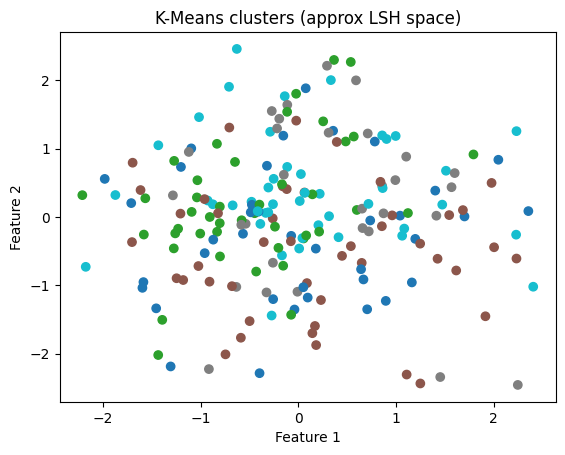

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt


n_clusters = 5 #For now we put the k-value as 5. 
#But we can later e.g. try to put it near the amount of different genres, or something corresponding.


# -----------------------------
# Run K-Means clustering
# -----------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(lsh_vectors)

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

print("\nCluster assignments:")
display( pd.DataFrame(df['cluster'].value_counts()) )

# -----------------------------
# Visualize
# -----------------------------
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=df['cluster'], cmap='tab10')
plt.title("K-Means clusters (approx LSH space)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


In [ ]:
#We can compare how well clusters align with the track genre:
pd.crosstab(df['track_genre'], df['cluster']) 

cluster,0,1,2,3,4
track_genre,,,,,
acoustic,1,0,0,0,0
afrobeat,0,0,0,0,1
alt-rock,0,0,2,1,0
alternative,0,1,0,0,0
ambient,2,1,1,0,0
...,...,...,...,...,...
synth-pop,0,0,0,0,1
tango,0,0,0,0,1
trance,1,0,1,0,1


### **CURE (Clustering Using REpresentatives) algorithm:**

Hierarchical clustering. Uses representative points instead of centroids. <br>
Might be more suitable for large datasets. 

In [ ]:
# #Pseudo CURE algorithm: 

# import numpy as np
# from sklearn.cluster import AgglomerativeClustering

# def simple_cure(X, n_clusters=5, shrink_factor=0.5, rep_points=10):
#     # Step 1: Hierarchical clustering
#     agg = AgglomerativeClustering(n_clusters=n_clusters)
#     labels = agg.fit_predict(X)
    
#     # Step 2: Compute representative points per cluster
#     reps = []
#     for k in range(n_clusters):
#         points = X[labels == k]
#         centroid = points.mean(axis=0)
#         dists = np.linalg.norm(points - centroid, axis=1)
#         farthest_idx = np.argsort(dists)[-rep_points:]
#         selected = points[farthest_idx]
#         reps.append(centroid + shrink_factor * (selected - centroid))
#     return labels, reps


/home/henrikk17/miniconda3/lib/python3.13/site-packages/sklearn/impute/_base.py:653: UserWarning: Skipping features without any observed values: ['explicit']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


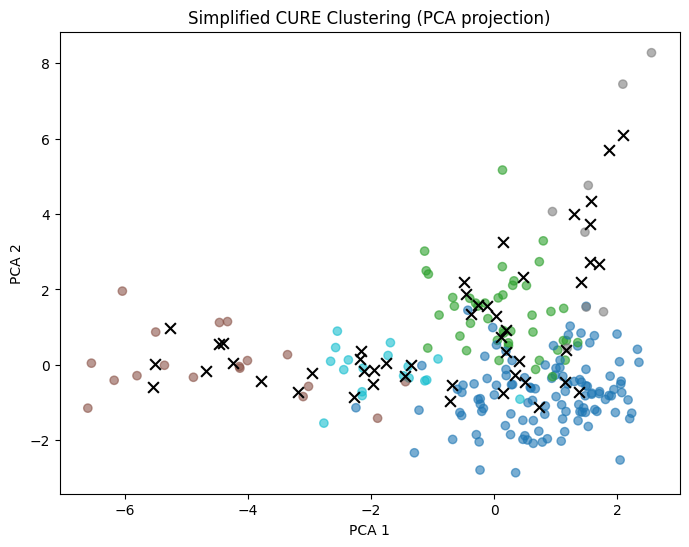

cluster
0    113
1     43
4     18
2     18
3      8
Name: count, dtype: int64


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
from sklearn.impute import SimpleImputer

# -----------------------------
# 1. Prepare data
# -----------------------------

#numeric_df = numeric_df.dropna() #Drop the NA values. We can also use imputer transformer, to approximate some value to fill in, as covered in the course. 

numeric_df = df.select_dtypes(include=[np.number])

# Impute missing values (NaN) with column mean
imputer = SimpleImputer(strategy="mean")
X_imputed = imputer.fit_transform(numeric_df)

# Scale
X = StandardScaler().fit_transform(X_imputed)


# -----------------------------
# 2. Simplified CURE algorithm
# -----------------------------
def simple_cure(X, n_clusters=5, shrink_factor=0.5, rep_points=10):
    # Step 1: Agglomerative clustering (approximation of CURE’s merging)
    agg = AgglomerativeClustering(n_clusters=n_clusters)
    labels = agg.fit_predict(X)
    
    # Step 2: Compute representative points for each cluster
    reps = []
    for k in range(n_clusters):
        points = X[labels == k]
        if len(points) == 0:
            continue
        centroid = points.mean(axis=0)
        dists = np.linalg.norm(points - centroid, axis=1)
        farthest_idx = np.argsort(dists)[-rep_points:]
        selected = points[farthest_idx]
        # shrink points toward the centroid
        rep_points_k = centroid + shrink_factor * (selected - centroid)
        reps.append(rep_points_k)
    return labels, reps

labels, reps = simple_cure(X, n_clusters=5, shrink_factor=0.5, rep_points=10)
df["cluster"] = labels

# -----------------------------
# 3. Visualize in 2D (via PCA)
# -----------------------------
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)

plt.figure(figsize=(8,6))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=labels, cmap="tab10", alpha=0.6)
plt.title("Simplified CURE Clustering (PCA projection)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

# Plot representative points (also projected to 2D)
for rep_set in reps:
    rep_2d = pca.transform(rep_set)
    plt.scatter(rep_2d[:, 0], rep_2d[:, 1], c="black", marker="x", s=60)

plt.show()

print(df["cluster"].value_counts())


In [ ]:
#pip install pyclustering

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from pyclustering.cluster.cure import cure
from pyclustering.utils import timedcall
import matplotlib.pyplot as plt

# -----------------------------
# 1. Load and prepare data
# -----------------------------
df = pd.read_csv("genre_avg_signatures.csv")
df = df.drop(columns=["Unnamed: 0"], errors="ignore")
df = df.sample(n=200, random_state=42)

numeric_df = df.select_dtypes(include=[np.number])
X = StandardScaler().fit_transform(numeric_df)

# -----------------------------
# 2. Run CURE clustering
# -----------------------------
# n_clusters: desired number of clusters
# number_rep_points: number of representative points per cluster
# compression: shrink factor (0–1)
n_clusters = 5
number_rep_points = 10
compression = 0.5

cure_instance = cure(data=X.tolist(),
                     number_cluster=n_clusters,
                     number_represent_points=number_rep_points,
                     compression=compression)

(ticks, _) = timedcall(cure_instance.process)
clusters = cure_instance.get_clusters()

# -----------------------------
# 3. Assign cluster labels
# -----------------------------
labels = np.empty(X.shape[0])
for cluster_id, indices in enumerate(clusters):
    labels[indices] = cluster_id

df['cluster'] = labels.astype(int)

print("Cluster counts:\n", df['cluster'].value_counts())

# -----------------------------
# 4. Visualize 2D projection
# -----------------------------
plt.scatter(X[:, 0], X[:, 1], c=df['cluster'], cmap='tab10')
plt.title("CURE clustering (approx view)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

### **DBSCAN (Density-Based Spatial Clustering of Applications with Noise):**

Density-based. Densly packed. <br>
Note: Usually works well on PCA or UMAP dimensionality-reduced data, but can struggle with high dimensionality. 

### **Graph-Based Clustering:**

- Nodes = songs
- Edges = similarity between songs (weighted)

Community detection to identify “music communities”

**Louvain algorithm**

Two-phase. Each note starts as a community. No user-defined K-value. Works decent on large data/ is scalable. 

**Spectral clustering**

Uses eigenvectors and K-means. Can be used on k-nearest neighbors graph (k-NN graph) from LSH. 

**Girvan-Newman Algorithm**

Can find communities. Might be tricky on large graphs, although limiting edges based on the LSH buckets, might help. 